In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt
import time

vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

def build_model(model_type):
    model = Sequential()
    model.add(Embedding(vocab_size, 64, input_length=max_len))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

models = ["RNN", "LSTM", "GRU"]
results = {}

for m in models:
    print(f"\nTraining {m} Model...")
    model = build_model(m)

    start = time.time()

    history = model.fit(
        x_train,
        y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2
    )

    end = time.time()

    test_loss, test_acc = model.evaluate(x_test, y_test)

    results[m] = {
        "history": history,
        "accuracy": test_acc,
        "time": end - start
    }

    print(f"{m} Test Accuracy: {test_acc}")
    print(f"{m} Training Time: {end - start:.2f} seconds")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training RNN Model...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 78ms/step - accuracy: 0.6442 - loss: 0.6190 - val_accuracy: 0.7856 - val_loss: 0.4715
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.7796 - loss: 0.4699 - val_accuracy: 0.7846 - val_loss: 0.4681
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.7934 - loss: 0.4413 - val_accuracy: 0.7886 - val_loss: 0.4663
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7898 - loss: 0.4577
RNN Test Accuracy: 0.7897999882698059
RNN Training Time: 74.69 seconds

Training LSTM Model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 156ms/step - accuracy: 0.7829 - loss: 0.4533 - val_accuracy: 0.8538 - val_loss: 0.3520
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 160ms/step - accuracy: 0.8979 - loss: 0.2605 - val_accuracy: 0.8642 - val_loss: 0.3201
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.9227 - loss: 0.2062 - val_accuracy: 0.8450 - val_loss: 0.3506
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8502

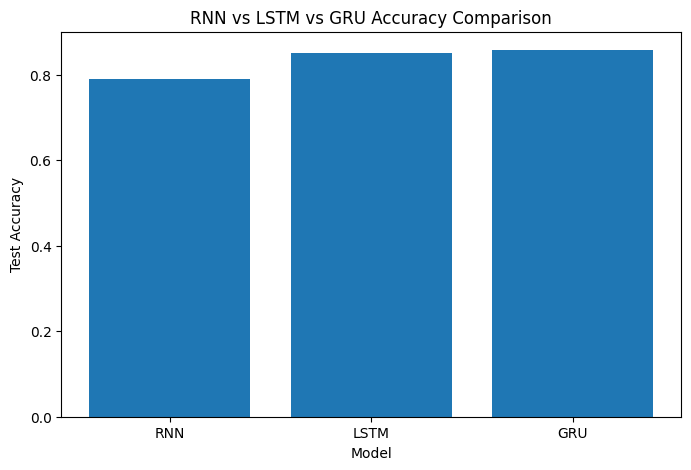

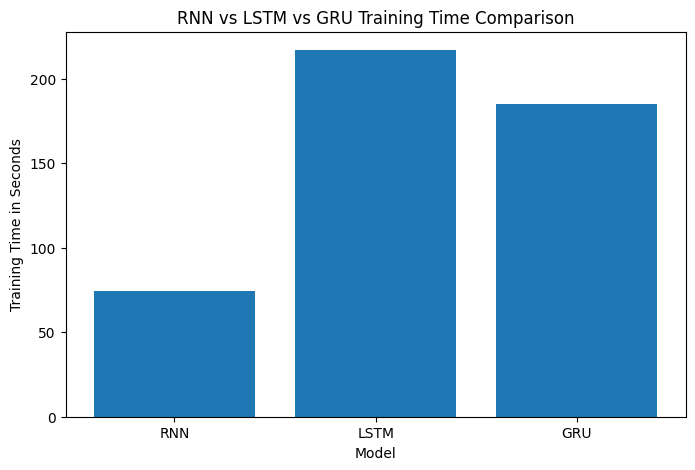

In [2]:
names = list(results.keys())
accuracies = [results[m]["accuracy"] for m in names]
times = [results[m]["time"] for m in names]

plt.figure(figsize=(8,5))
plt.bar(names, accuracies)
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(names, times)
plt.title("RNN vs LSTM vs GRU Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time in Seconds")
plt.show()
